Code for Experiment S1
----------------------

This notebook contains the python code used to analyze the data collected during Experiment S1 of the paper "Building Compressed Causal Models of the World."

In [1]:
#Import all required packages.

import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm
import scipy.stats as stats

The following block of code imports and cleans the data in the file 'study_s3_data.csv'. Be sure that this file is saved in the same folder as your notebook.

In [2]:
data = pd.read_csv('study_s3_data.csv')
data=data.drop(labels=0,axis=0) 
data=data.drop(labels=1,axis=0)
exclusions = []
for i in range(2,len(data)):
    if data.CharSel[i] != data.Checker[i] or '95' not in data.CompCheck[i]:
        exclusions = np.append(exclusions,i)
data = data.drop(labels=exclusions,axis=0)
data = data.reset_index()

The following block of code calculates the proportion of participants in the low-information-loss condition, for whom a less compressed representation cost 20 gold coins, who chose the less compressed representation.

In [3]:
count_ll_hv = 0
count_ll_hv_coarse = 0
for i in range(len(data)):
    if data.loss[i] == 'low' and data.cost[i] == '20':
        count_ll_hv = count_ll_hv + 1
        if data.NoteCardChoice_LL[i] == 'A note card that says "Mushrooms are stronger than flowers." Cost: 10 Gold Coins.':
            count_ll_hv_coarse = count_ll_hv_coarse + 1
[1-count_ll_hv_coarse/count_ll_hv]

[0.3846153846153846]

The following block of code calculates the proportion of participants in the high-information-loss condition, for whom a less compressed representation cost 20 gold coins, who chose the less compressed representation.

In [4]:
count_hl_hv = 0
count_hl_hv_coarse = 0
for i in range(len(data)):
    if data.loss[i] == 'high' and data.cost[i] == '20':
        count_hl_hv = count_hl_hv + 1
        if data.NoteCardChoice_HL[i] == 'A note card that says "Mushrooms are stronger than flowers." Cost: 10 Gold Coins.':
            count_hl_hv_coarse = count_hl_hv_coarse + 1
[1-count_hl_hv_coarse/count_hl_hv]

[0.38235294117647056]

The following block of code calculates the proportion of participants in the low-information-loss condition, for whom a less compressed representation cost 12 gold coins, who chose the less compressed representation.

In [5]:
count_ll_mv = 0
count_ll_mv_coarse = 0
for i in range(len(data)):
    if data.loss[i] == 'low' and data.cost[i] == '12':
        count_ll_mv = count_ll_mv + 1
        if data.NoteCardChoice_LL[i] == 'A note card that says "Mushrooms are stronger than flowers." Cost: 10 Gold Coins.':
            count_ll_mv_coarse = count_ll_mv_coarse + 1
[1-count_ll_mv_coarse/count_ll_mv]

[0.6060606060606061]

The following block of code calculates the proportion of participants in the high-information-loss condition, for whom a less compressed representation cost 12 gold coins, who chose the less compressed representation.

In [6]:
count_hl_mv = 0
count_hl_mv_coarse = 0
for i in range(len(data)):
    if data.loss[i] == 'high' and data.cost[i] == '12':
        count_hl_mv = count_hl_mv + 1
        if data.NoteCardChoice_HL[i] == 'A note card that says "Mushrooms are stronger than flowers." Cost: 10 Gold Coins.':
            count_hl_mv_coarse = count_hl_mv_coarse + 1
[1-count_hl_mv_coarse/count_hl_mv]

[0.6071428571428572]

The following block of code calculates the proportion of participants in the low-information-loss condition, for whom a less compressed representation cost 10 gold coins, who chose the less compressed representation.

In [7]:
count_ll_nv = 0
count_ll_nv_coarse = 0
for i in range(len(data)):
    if data.loss[i] == 'low' and data.cost[i] == '10':
        count_ll_nv = count_ll_nv + 1
        if data.NoteCardChoice_LL[i] == 'A note card that says "Mushrooms are stronger than flowers." Cost: 10 Gold Coins.':
            count_ll_nv_coarse = count_ll_nv_coarse + 1
[1-count_ll_nv_coarse/count_ll_nv]

[1.0]

The following block of code calculates the proportion of participants in the high-information-loss condition, for whom a less compressed representation cost 10 gold coins, who chose the less compressed representation.

In [8]:
count_hl_nv = 0
count_hl_nv_coarse = 0
for i in range(len(data)):
    if data.loss[i] == 'high' and data.cost[i] == '10':
        count_hl_nv = count_hl_nv + 1
        if data.NoteCardChoice_HL[i] == 'A note card that says "Mushrooms are stronger than flowers." Cost: 100 Gold Coins.':
            count_hl_nv_coarse = count_hl_nv_coarse + 1
[1-count_hl_nv_coarse/count_hl_nv]

[1.0]

The next block produces the figure showing the main results of the experiment.

/var/folders/09/dm7f60811cqgm3lr35c86qfw0000gn/T/ipykernel_40723/1692640270.py:28: UserWarning: FixedFormatter should only be used together with FixedLocator
  fig.set_yticklabels(labels=['0','.2','.4','.6','.8','1'],fontsize=30)


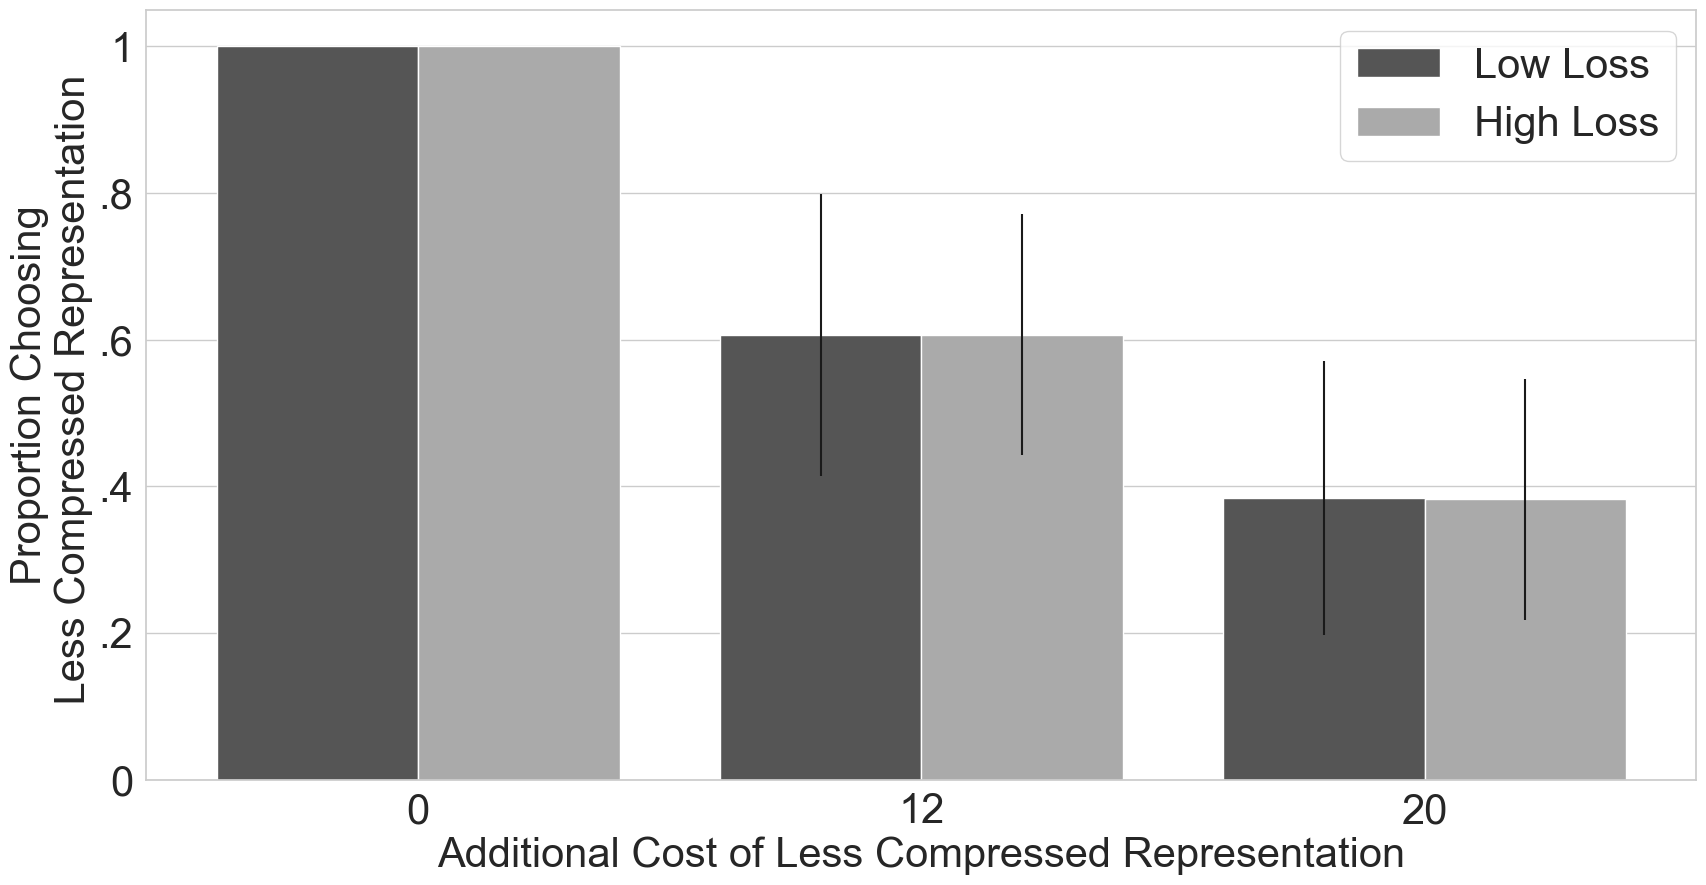

In [9]:
df = pd.DataFrame({'Cost':[0,12,20],
                   'Low Loss':[1-count_ll_nv_coarse/count_ll_nv,1-count_ll_mv_coarse/count_ll_mv,1-count_ll_hv_coarse/count_ll_hv],
                   'High Loss':[1-count_hl_nv_coarse/count_hl_nv,1-count_hl_mv_coarse/count_hl_mv,1-count_hl_hv_coarse/count_hl_hv]
})

melted = pd.melt(df, id_vars=['Cost'], value_vars=['Low Loss','High Loss'],var_name='')

def interval(x,arr):
    return 1.96*np.sqrt((x/np.sum([arr]))*((np.sum(arr)-x)/np.sum(arr))/np.sum(arr))

yerr = [interval(count_ll_nv_coarse,[count_ll_nv_coarse,count_ll_mv_coarse,count_ll_hv_coarse]),\
       interval(count_ll_mv_coarse,[count_ll_nv_coarse,count_ll_mv_coarse,count_ll_mv_coarse]),\
        interval(count_ll_hv_coarse,[count_ll_nv_coarse,count_ll_mv_coarse,count_ll_mv_coarse]),\
       interval(count_hl_nv_coarse,[count_hl_nv_coarse,count_hl_mv_coarse,count_hl_hv_coarse]),\
       interval(count_hl_mv_coarse,[count_hl_nv_coarse,count_hl_mv_coarse,count_hl_hv_coarse]),\
       interval(count_hl_hv_coarse,[count_hl_nv_coarse,count_hl_mv_coarse,count_hl_hv_coarse])]


sns.set(rc={'figure.figsize':(20,10)})
sns.set_style("whitegrid")
fig = sns.barplot(data=melted,x='Cost',y='value',hue='',palette="gray")
x_coords = [p.get_x() + 0.5*p.get_width() for p in fig.patches]
y_coords = [p.get_height() for p in fig.patches]
plt.errorbar(x=x_coords, y=y_coords, yerr=yerr, fmt="none", c= "k")
fig.set_xlabel('Additional Cost of Less Compressed Representation',fontsize=30)
fig.set_ylabel('Proportion Choosing\n Less Compressed Representation',fontsize=30)
fig.set_xticklabels(labels=['0','12','20'],fontsize=30)
fig.set_yticklabels(labels=['0','.2','.4','.6','.8','1'],fontsize=30)
plt.legend(fontsize=30)
plt.savefig('Compression By Cost of Fine-Graining and Loss - S3')

The next block performs a binary logistic regression of a variable representing whether the participant chooses the less compressed data representation against the cost of the representation and the amount of information loss inherent in choosing the more compressed representation.

In [12]:
coarse_bin = np.array([0 if data.NoteCardChoice_LL[i] == 'A note card that says "Mushrooms are stronger than flowers." Cost: 10 Gold Coins.'\
              or data.NoteCardChoice_HL[i] == 'A note card that says "Mushrooms are stronger than flowers." Cost: 10 Gold Coins.'\
              else 1 for i in range(len(data))])
cost = np.array([int(data.cost[i])-10 for i in range(len(data))])   
loss = np.array([-1 if data.loss[i] == 'low' else 1 for i in range(len(data))])
cost_loss = np.array([cost[i]*loss[i] for i in range(len(data))])
arr = np.hstack((coarse_bin.reshape(-1,1),cost.reshape(-1,1),loss.reshape(-1,1),cost_loss.reshape(-1,1)))
df = pd.DataFrame(arr,columns = ['Coarse','Cost','Loss','Cost:Loss'])
X = sm.add_constant(df[['Cost','Loss']])
y = df['Coarse']
logit_model=sm.Logit(y,X)
result=logit_model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.547898
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:                 Coarse   No. Observations:                  184
Model:                          Logit   Df Residuals:                      181
Method:                           MLE   Df Model:                            2
Date:                Thu, 11 May 2023   Pseudo R-squ.:                  0.1520
Time:                        08:03:01   Log-Likelihood:                -100.81
converged:                       True   LL-Null:                       -118.88
Covariance Type:            nonrobust   LLR p-value:                 1.424e-08
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.5985      0.253      6.322      0.000       1.103       2.094
Cost          -0.2201      0.

The next block performs a binary logistic regression of a variable representing whether the participant chooses the less compressed data representation against the cost of the representation, the amount of information loss inherent in choosing the more compressed representation, and the interaction between the two.

In [11]:
coarse_bin = np.array([0 if data.NoteCardChoice_LL[i] == 'A note card that says "Mushrooms are stronger than flowers." Cost: 10 Gold Coins.'\
              or data.NoteCardChoice_HL[i] == 'A note card that says "Mushrooms are stronger than flowers." Cost: 10 Gold Coins.'\
              else 1 for i in range(len(data))])
cost = np.array([int(data.cost[i])-10 for i in range(len(data))])   
loss = np.array([-1 if data.loss[i] == 'low' else 1 for i in range(len(data))])
cost_loss = np.array([cost[i]*loss[i] for i in range(len(data))])
arr = np.hstack((coarse_bin.reshape(-1,1),cost.reshape(-1,1),loss.reshape(-1,1),cost_loss.reshape(-1,1)))
df = pd.DataFrame(arr,columns = ['Coarse','Cost','Loss','Cost:Loss'])
X = sm.add_constant(df[['Cost','Loss','Cost:Loss']])
y = df['Coarse']
logit_model=sm.Logit(y,X)
result=logit_model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.546925
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:                 Coarse   No. Observations:                  184
Model:                          Logit   Df Residuals:                      180
Method:                           MLE   Df Model:                            3
Date:                Thu, 11 May 2023   Pseudo R-squ.:                  0.1535
Time:                        08:02:20   Log-Likelihood:                -100.63
converged:                       True   LL-Null:                       -118.88
Covariance Type:            nonrobust   LLR p-value:                 5.890e-08
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.6018      0.253      6.321      0.000       1.105       2.099
Cost          -0.2220      0.